# PIPELINE IMPROVEMENT

Replace the current pipeline with a more efficient oine that is focused on one task only.

HEATMAPPING:


In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pandas as pd

In [105]:
df = pd.read_csv("./data/r2.csv",keep_default_na=False)
df["REPETITION"] = df["REPETITION"].astype(np.uint8)
df["QUESTION_NUM"] = df["QUESTION_NUM"].astype(np.uint8)
#get video number Robusto2_XXX and convert to int8
def get_video_num(video_str):
    try:
        return int(video_str.split("_")[1])
    except (IndexError, ValueError):
        return np.nan
df["VIDEO"] = df["VIDEO"].astype("category").cat.codes.astype("uint8")
df["AGENT"] = df["AGENT"].astype("category").cat.codes.astype("uint8")


#check for non strings in the ANSWER column
non_string_answers = df[~df['ANSWER'].apply(lambda x: isinstance(x, str))]
print("Non-string answers:")
print(non_string_answers)

df.info()

Non-string answers:
Empty DataFrame
Columns: [AGENT, VIDEO, BLOCK, QUESTION_NUM, REPETITION, ANSWER]
Index: []
<class 'pandas.DataFrame'>
RangeIndex: 86000 entries, 0 to 85999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   AGENT         86000 non-null  uint8
 1   VIDEO         86000 non-null  uint8
 2   BLOCK         86000 non-null  int64
 3   QUESTION_NUM  86000 non-null  uint8
 4   REPETITION    86000 non-null  uint8
 5   ANSWER        86000 non-null  str  
dtypes: int64(1), str(1), uint8(4)
memory usage: 9.6 MB


In [106]:
#build cache
obj_cache = {} #str -> object
row_map = {} # row_key -> object

In [107]:
def get_row_key(row):
    return (row["AGENT"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION"])

loaded_strings = set(df["ANSWER"].unique())
current_strings = set(obj_cache.keys())

#now get the strings that are in the dataframe but not in the cache
strings_to_load = loaded_strings - current_strings

objecter = lambda s: len(s)

#now we can execute the 
for s in strings_to_load:
    obj_cache[s] = objecter(s)
#ahora construir row_map
for row in df.itertuples(index=False):
    row_key = (row.AGENT, row.VIDEO, row.QUESTION_NUM, row.REPETITION)
    row_map[row_key] = obj_cache[row.ANSWER]

In [108]:
#now build the comparations 
KEYS = ["VIDEO", "QUESTION_NUM", "AGENT", "REPETITION"]

df_comp = pd.merge(df[KEYS], df[KEYS], on=["VIDEO", "QUESTION_NUM"], suffixes=('_I', '_J')) 
df_comp.head(20)

,VIDEO,QUESTION_NUM,AGENT_I,REPETITION_I,AGENT_J,REPETITION_J
0,3,1,10,1,10,1
1,3,1,10,1,12,1
2,3,1,10,1,13,1
3,3,1,10,1,14,1
4,3,1,10,1,15,1
5,3,1,10,1,16,1
6,3,1,10,1,17,1
7,3,1,10,1,18,1
8,3,1,10,1,19,1
9,3,1,10,1,11,1


In [ ]:
#now apply the comparations getting the pre_processed answers from the cache
def comparation_func(row : list, cache : list):
    key_i = (row["AGENT_I"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION_I"])
    key_j = (row["AGENT_J"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION_J"])
    
    pre_processed_i = cache.get(key_i, None)
    pre_processed_j = cache.get(key_j, None)
    
    if pre_processed_i is not None and pre_processed_j is not None:
        #compute some comparation between the two pre-processed answers, in this case we just compute the absolute difference
        return abs(pre_processed_i - pre_processed_j)
    else:
        return np.nan

df_comp["RESULT"] = df_comp.progress_apply(lambda row: comparation_func(row, row_map), axis=1)

  0%|                                                                                                                                                                             | 0/4622500 [00:00<?, ?it/s]

   VIDEO  QUESTION_NUM  AGENT_I  REPETITION_I  AGENT_J  REPETITION_J
0      3             1       10             1       10             1
1      3             1       10             1       12             1
2      3             1       10             1       13             1
3      3             1       10             1       14             1


In [110]:
df_comp.head(20)

,VIDEO,QUESTION_NUM,AGENT_I,REPETITION_I,AGENT_J,REPETITION_J
0,3,1,10,1,10,1
1,3,1,10,1,12,1
2,3,1,10,1,13,1
3,3,1,10,1,14,1
4,3,1,10,1,15,1
5,3,1,10,1,16,1
6,3,1,10,1,17,1
7,3,1,10,1,18,1
8,3,1,10,1,19,1
9,3,1,10,1,11,1


In [111]:
agg_df = (
    df_comp
    .groupby(
        ["VIDEO", "QUESTION_NUM", "AGENT_I", "AGENT_J"],
        as_index=False
    )["RESULT"]
    .mean()
)
agg_df.head(5)


KeyError: 'Column not found: RESULT'

In [ ]:
#now add blocks
def assign_block(row):
    if row["QUESTION_NUM"] <= 5:
        return 1
    elif row["QUESTION_NUM"] <= 10:
        return 2
    elif row["QUESTION_NUM"] <= 15:
        return 3
    else:
        return 4
agg_df["BLOCK"] = agg_df.apply(assign_block, axis=1)

agg_df2 = (
    agg_df
    .groupby(
        ["AGENT_I", "AGENT_J", "BLOCK"],
        as_index=False
    )["RESULT"]
    .mean()
)   
agg_df2.head(20)

,AGENT_I,AGENT_J,BLOCK,RESULT
0,0,0,1,29.85505
1,0,0,2,0.00605
2,0,0,3,38.91300
3,0,0,4,24.85040
4,0,1,1,34.44345
5,0,1,2,0.11995
6,0,1,3,42.49605
7,0,1,4,99.04470
8,0,2,1,45.95565
9,0,2,2,151.22170


In [ ]:
#now pivot the table to have the agents as rows and columns and the blocks as values
BLOCK_TO_PLOT = 1
df_block = agg_df2[agg_df2["BLOCK"] == BLOCK_TO_PLOT]
#now pivot it using the X and Y as the agents and the values as the result
heatmap_data = df_block.pivot(index="AGENT_I", columns="AGENT_J", values="RESULT")

Text(0.5, 1.0, 'Heatmap of Mean Result for Block 1')

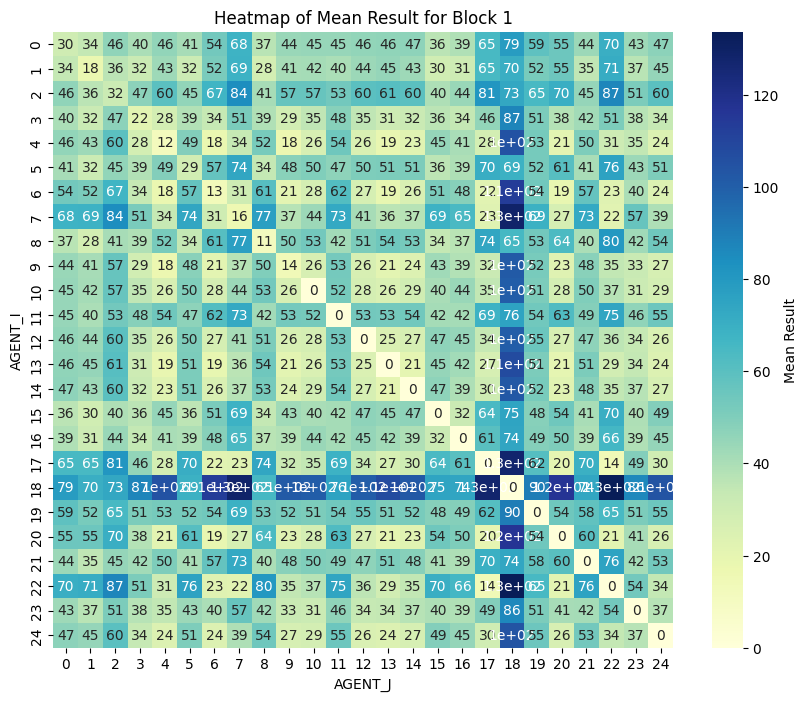

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Mean Result'})
plt.title(f"Heatmap of Mean Result for Block {BLOCK_TO_PLOT}")